# AI Tools for Public Safety: EMS Demand Prediction
**CAI 4930 | Group Project | University of West Florida**

## Project Overview
Using historical 911 dispatch data from Montgomery County, PA (2015–2020), this notebook builds machine learning classification models to predict EMS demand levels on the time of day and helps build relationships to better help with EMS deployment.

## Dataset
- **Source:** Montgomery County 911 Calls — Kaggle
- **File used:** `911_ems_only.csv`

## Notebook Structure
1. Setup & Imports
2. Data Filtering & Loading
3. Vectorization & Feature Engineering
4. Exploratory Data Analysis (EDA)
5. Target Variable Creation
6. Model Training & Comparison
7. Results & Evaluation
8. Prediction Demo

## Requirements (Copy and paste into a terminal outside of the notebook)
```
pip install pandas scikit-learn matplotlib seaborn xgboost holidays
```

## Instructions
- Clear all cell outputs before starting
- Run each cell in order, skipping the first cell
- Update the `pd.read_csv` path in Step 2 to match your local file path

## Authors
Keanu Pho
Matt Sulack


## First Cell (Reference Only — Do Not Run)
Shows how the original dataset was filtered to EMS-only incidents.
The filtered file `911_ems_only.csv` is already included in the GitHub repository.

In [43]:
import pandas as pd

df_full = pd.read_csv('911.csv')
ems_df = df_full[df_full['title'].str.startswith('EMS')]
ems_df.to_csv('911_ems_only.csv', index=False)

print(f'Original rows: {len(df_full):,}')
print(f'EMS only rows: {len(ems_df):,}')


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Original rows: 663,522
EMS only rows: 332,692


## Step 1: Import Required Libraries
Imports all libraries needed for data processing, visualization, and machine learning.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score)
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

print("All libraries loaded successfully.")


All libraries loaded successfully.


## Step 2: Load Dataset
Load the EMS_only filtered dataset. Update the file path if needed.

In [3]:
# Replace '911_ems_only.csv' with your file path if needed
df = pd.read_csv('/Users/keanupho/Downloads/911_ems_only.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nFirst 5 rows:')
df.head()


Dataset shape: (332692, 9)

Columns: ['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr', 'e']

First 5 rows:


,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1
3,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1
4,40.253473,-75.283245,CANNON AVE & W 9TH ST; LANSDALE; Station 345;...,19446.0,EMS: HEAD INJURY,2015-12-10 15:39:04,LANSDALE,CANNON AVE & W 9TH ST,1


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
lat              0
lng              0
desc             0
zip          27837
title            0
timeStamp        0
twp            212
addr             0
e                0
dtype: int64


## Step 3: Vectorization & Feature Engineering
Parse timestamps, encode call types, townships, day of week, seasons, and holidays.

### 3a: Parse Timestamps

In [36]:
# Parse timestamps
# extract hour and month as primary temporal features
df['timeStamp'] = pd.to_datetime(df['timeStamp'])
df['hour'] = df['timeStamp'].dt.hour
df['month'] = df['timeStamp'].dt.month
df['day_of_week'] = df['timeStamp'].dt.dayofweek  # 0 = Monday, 6 = Sunday

print("Timestamps extracted.")
df[['timeStamp', 'hour', 'month', 'day_of_week']].head()


Timestamps extracted.


,timeStamp,hour,month,day_of_week
0,2015-12-10 17:10:52,17,12,3
1,2015-12-10 17:29:21,17,12,3
2,2015-12-10 16:47:36,16,12,3
3,2015-12-10 16:56:52,16,12,3
4,2015-12-10 15:39:04,15,12,3


### 3b: Encode Call Types
One hot encode each EMS call type into binary columns.

In [6]:
# Isolate call type by stripping the "EMS: " prefix
df['call_type'] = df['title'].str.replace('EMS: ', '', regex=False)

# One hot encode each call type into binary columns
call_type_dummies = pd.get_dummies(df['call_type'], prefix='type')
df = pd.concat([df, call_type_dummies], axis=1)

print(f'Unique call types encoded: {len(call_type_dummies.columns)}')
print(f'Dataset shape after call type encoding: {df.shape}')


Unique call types encoded: 81
Dataset shape after call type encoding: (332692, 94)


### 3c: Encode Townships
Add geographic feature (township where the incident occurred)

In [7]:
# Fill missing township values with unknown
df['twp'] = df['twp'].fillna('UNKNOWN')

# One hot encode townships into binary columns
twp_dummies = pd.get_dummies(df['twp'], prefix='twp')
df = pd.concat([df, twp_dummies], axis=1)

print(f'Unique townships encoded: {len(twp_dummies.columns)}')
print(f'Dataset shape after township encoding: {df.shape}')
print(f'\nTop 10 townships by call volume:')
print(df['twp'].value_counts().head(10).to_string())


Unique townships encoded: 69
Dataset shape after township encoding: (332692, 163)

Top 10 townships by call volume:
twp
NORRISTOWN          24774
LOWER MERION        21578
ABINGTON            20617
POTTSTOWN           17425
LOWER PROVIDENCE    14748
CHELTENHAM          14351
UPPER MERION        14103
UPPER MORELAND      11979
HORSHAM              8644
EAST NORRITON        8450


### 3d: Add Season
Derive season from month to capture broader weather-related demand patterns.

In [8]:
# Derive season from month
# Winter: Dec-Feb, Spring: Mar-May, Summer: Jun-Aug, Fall: Sep-Nov
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['month'].apply(get_season)

# One hot encode season
season_dummies = pd.get_dummies(df['season'], prefix='season')
df = pd.concat([df, season_dummies], axis=1)

print("Season distribution:")
print(df['season'].value_counts().to_string())


Season distribution:
season
Winter    88074
Spring    87947
Summer    83949
Fall      72722


### 3e: Add Holiday Flag
Flag incidents that occurred on Pennsylvania state or federal holidays.

In [9]:
# Flag incidents occurring on PA holidays
pa_holidays = holidays.US(state='PA', years=range(2015, 2021))
df['is_holiday'] = df['timeStamp'].dt.date.apply(
    lambda x: 1 if x in pa_holidays else 0
)

print(f'Holiday incidents: {df["is_holiday"].sum():,}')
print(f'Non-holiday incidents: {(df["is_holiday"] == 0).sum():,}')


Holiday incidents: 10,473
Non-holiday incidents: 322,219


## Step 4: Exploratory Data Analysis 
Visualize patterns in the data before model training

### 4a: Average EMS Call Volume by Hour of Day

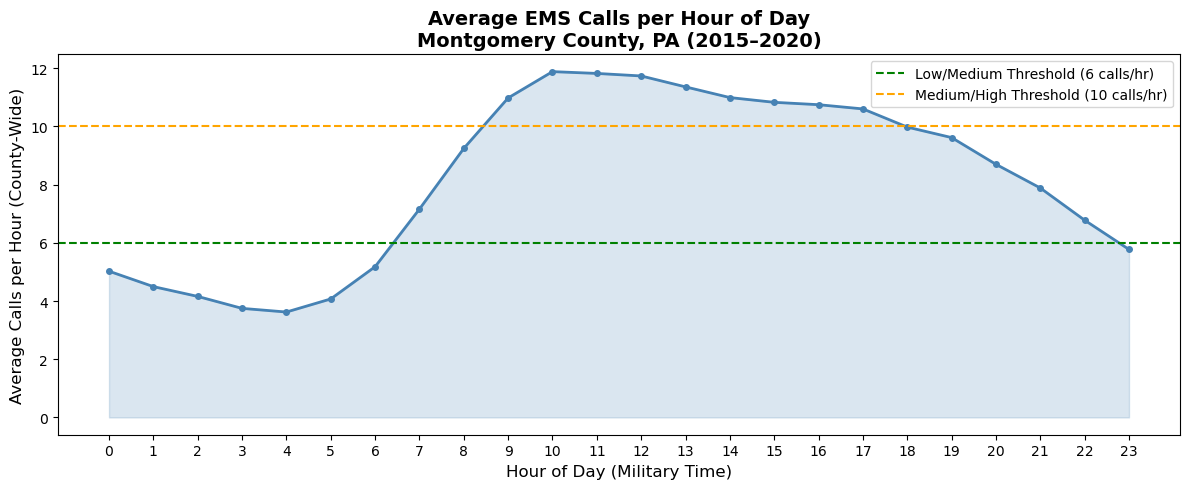

In [41]:
df['date_hour'] = df['timeStamp'].dt.floor('h')
hourly_counts = df.groupby('date_hour').size().reset_index(name='call_count')

num_days = df['timeStamp'].dt.date.nunique()
hourly_avg = df.groupby('hour').size() / num_days

plt.figure(figsize=(12, 5))
plt.plot(hourly_avg.index, hourly_avg.values, color='steelblue', linewidth=2, marker='o', markersize=4)
plt.fill_between(hourly_avg.index, hourly_avg.values, alpha=0.2, color='steelblue')
plt.axhline(y=6, color='green', linestyle='--', linewidth=1.5, label='Low/Medium Threshold (6 calls/hr)')
plt.axhline(y=10, color='orange', linestyle='--', linewidth=1.5, label='Medium/High Threshold (10 calls/hr)')
plt.title('Average EMS Calls per Hour of Day\nMontgomery County, PA (2015–2020)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (Military Time)', fontsize=12)
plt.ylabel('Average Calls per Hour (County-Wide)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
# plt.savefig('avg_calls_by_hour.png', dpi=150)  # uncomment to save
plt.show()


### 4b: EMS Call Volume Heatmap: Hour of Day vs Month

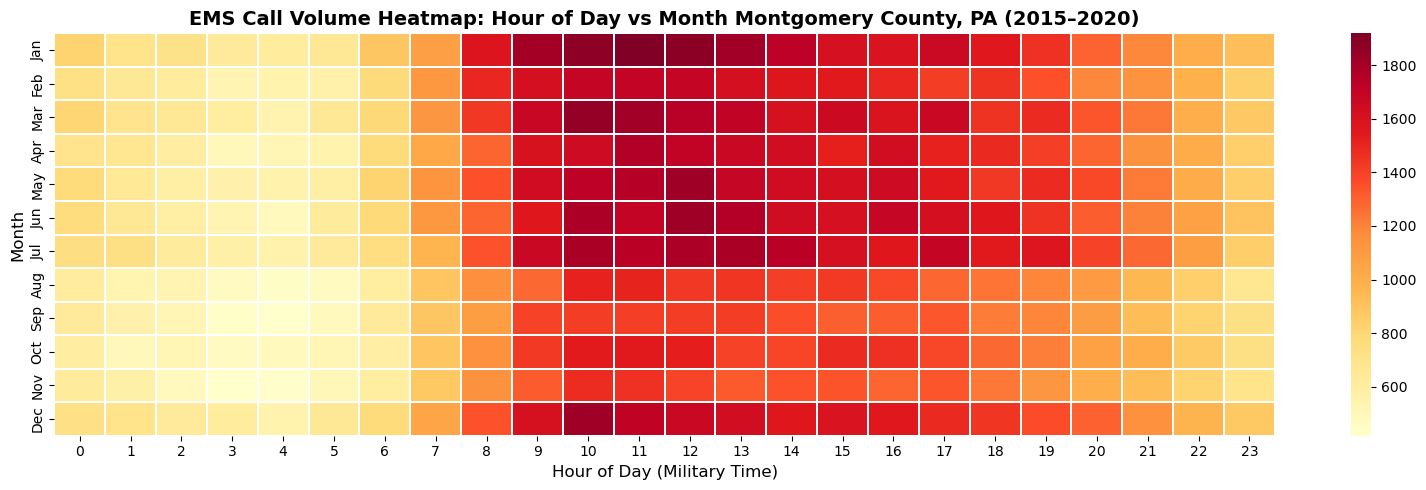

In [37]:
pivot = df.groupby(['month', 'hour']).size().unstack()
pivot.index = ['Jan','Feb','Mar','Apr','May','Jun', 'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3)
plt.title('EMS Call Volume Heatmap: Hour of Day vs Month Montgomery County, PA (2015–2020)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (Military Time)', fontsize=12)
plt.ylabel('Month', fontsize=12)
plt.tight_layout()
# plt.savefig('heatmap_hour_month.png', dpi=150)  # uncomment to save
plt.show()


### 4c: EMS Call Volume Heatmap: Hour of Day vs Township
Shows which townships have high demand at specific hours.
Helps illustrate the use of AI and the planning and positioning of EMS for deployment and response purposes

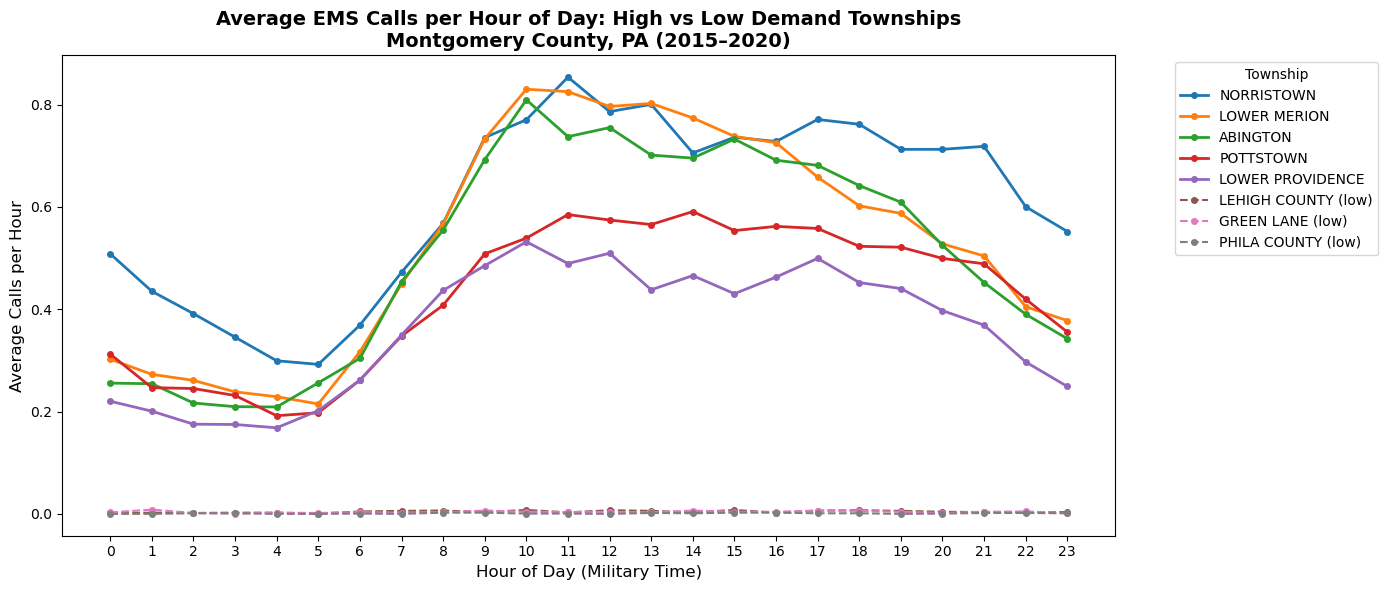

In [40]:
# Top 5 and bottom 3 townships by call volume
top_5_twp = df['twp'].value_counts().head(5).index.tolist()
bottom_3_twp = df['twp'].value_counts().tail(3).index.tolist()
selected_twp = top_5_twp + bottom_3_twp

df_selected_twp = df[df['twp'].isin(selected_twp)]

# Average calls per hour per day
num_days = df['timeStamp'].dt.date.nunique()
pivot_twp = df_selected_twp.groupby(['twp', 'hour']).size().unstack(fill_value=0)
pivot_twp_avg = pivot_twp / num_days

plt.figure(figsize=(14, 6))
for twp in top_5_twp:
    plt.plot(pivot_twp_avg.columns, pivot_twp_avg.loc[twp], marker='o', markersize=4, label=twp, linewidth=2)

for twp in bottom_3_twp:
    plt.plot(pivot_twp_avg.columns, pivot_twp_avg.loc[twp], marker='o', markersize=4, label=f'{twp} (low)', linewidth=1.5, linestyle='--')

plt.title('Average EMS Calls per Hour of Day: High vs Low Demand Townships\nMontgomery County, PA (2015–2020)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (Military Time)', fontsize=12)
plt.ylabel('Average Calls per Hour', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title='Township', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
# plt.savefig('township_high_vs_low.png', dpi=150)  # uncomment to save
plt.show()

### 4d: Top 15 EMS Call Types by Volume

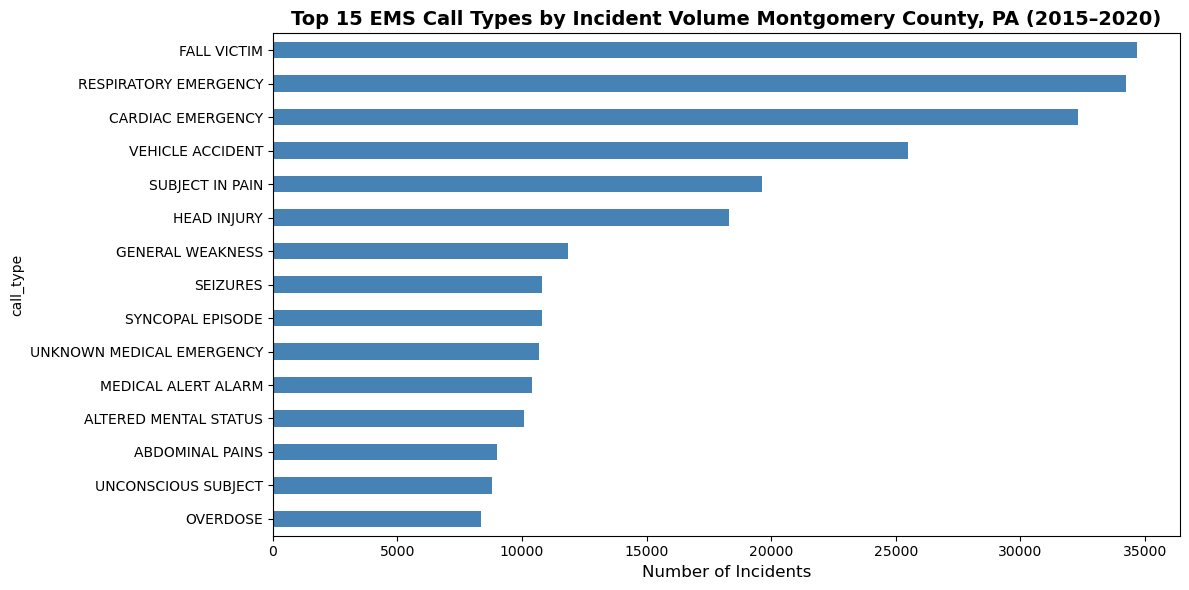

In [14]:
top_calls = df['call_type'].value_counts().head(15)

plt.figure(figsize=(12, 6))
top_calls.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 EMS Call Types by Incident Volume Montgomery County, PA (2015–2020)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Incidents', fontsize=12)
plt.tight_layout()
# plt.savefig('top_15_call_types.png', dpi=150)  # uncomment to save
plt.show()


### 4e: Top 5 Call Types by Day of Week
Explores causal relationships (do certain incident types occur more on specific days?)

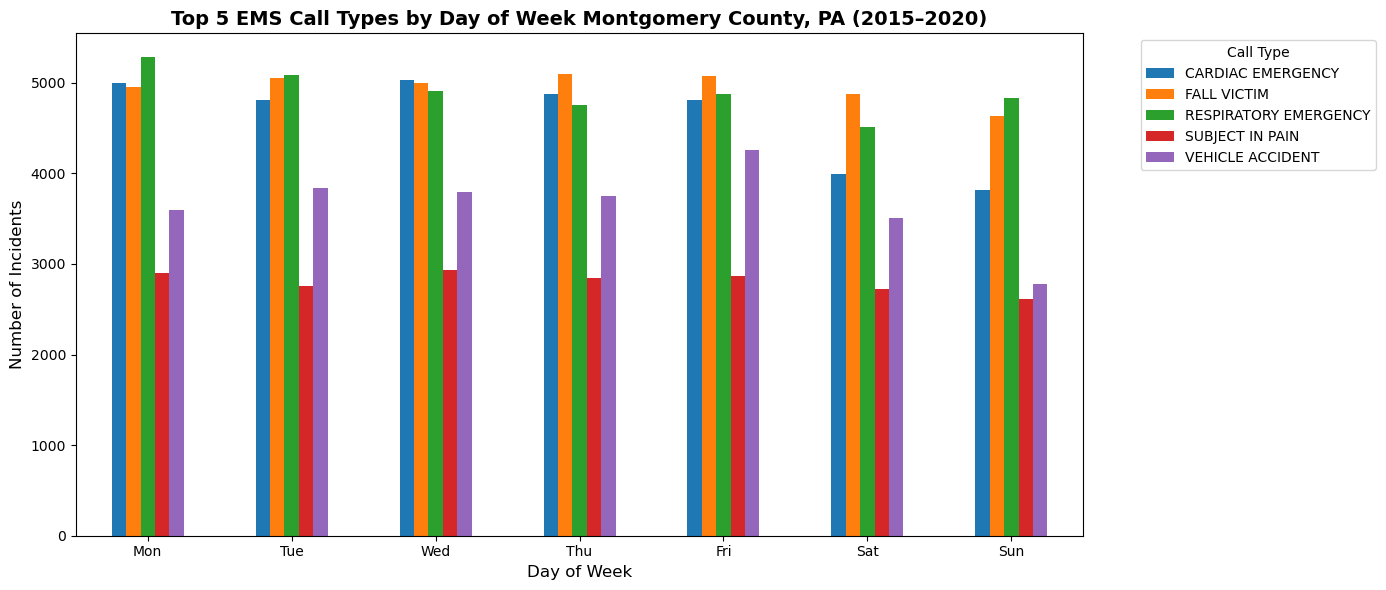

In [15]:
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df['day_label'] = df['day_of_week'].map(dict(enumerate(day_labels)))

# Focus on top 5 call types
top_5 = df['call_type'].value_counts().head(5).index.tolist()
df_top5 = df[df['call_type'].isin(top_5)]

pivot_calls = df_top5.groupby(['day_label', 'call_type']).size().unstack()
pivot_calls = pivot_calls.reindex(day_labels)

pivot_calls.plot(kind='bar', figsize=(14, 6))
plt.title('Top 5 EMS Call Types by Day of Week Montgomery County, PA (2015–2020)', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.legend(title='Call Type', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
# plt.savefig('call_types_by_day.png', dpi=150)  # uncomment to save
plt.show()


### 4f: Holiday vs Non-Holiday Call Volume
Do holidays significantly affect EMS demand?

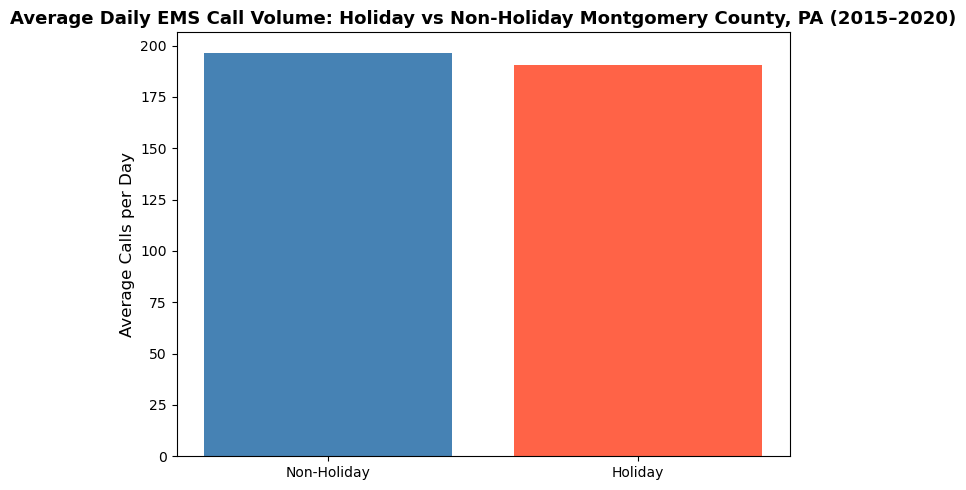

Average calls per non-holiday day: 196.6
Average calls per holiday day:     190.4


In [39]:
holiday_avg = df.groupby('is_holiday')['hour'].count()
labels = ['Non-Holiday', 'Holiday']
values = [holiday_avg.get(0, 0), holiday_avg.get(1, 0)]

# Normalize by number of days in each category
holiday_days = df[df['is_holiday'] == 1]['timeStamp'].dt.date.nunique()
non_holiday_days = df[df['is_holiday'] == 0]['timeStamp'].dt.date.nunique()

avg_holiday = values[1] / holiday_days if holiday_days > 0 else 0
avg_non_holiday = values[0] / non_holiday_days if non_holiday_days > 0 else 0

plt.figure(figsize=(7, 5))
plt.bar(['Non-Holiday', 'Holiday'], [avg_non_holiday, avg_holiday], color=['steelblue', 'tomato'])
plt.title('Average Daily EMS Call Volume: Holiday vs Non-Holiday Montgomery County, PA (2015–2020)', fontsize=13, fontweight='bold')
plt.ylabel('Average Calls per Day', fontsize=12)
plt.tight_layout()
# plt.savefig('holiday_vs_nonholiday.png', dpi=150)  # uncomment to save
plt.show()

print(f'Average calls per non-holiday day: {avg_non_holiday:.1f}')
print(f'Average calls per holiday day: {avg_holiday:.1f}')


### 4g: Seasonal Differences

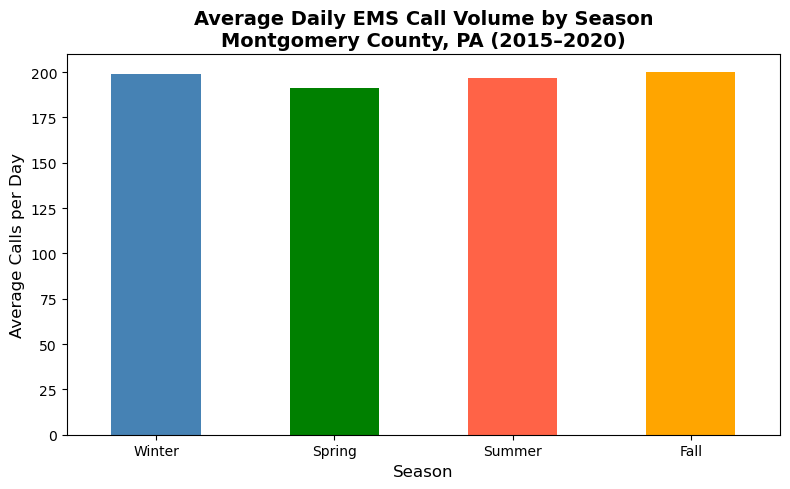

In [46]:
# Average calls per day by season
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_days = df.groupby('season')['timeStamp'].apply(lambda x: x.dt.date.nunique())
season_counts = df.groupby('season').size()
season_avg = (season_counts / season_days).reindex(season_order)

plt.figure(figsize=(8, 5))
season_avg.plot(kind='bar', color=['steelblue', 'green', 'tomato', 'orange'])
plt.title('Average Daily EMS Call Volume by Season\nMontgomery County, PA (2015–2020)', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Calls per Day', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
# plt.savefig('calls_by_season.png', dpi=150)  # uncomment to save
plt.show()

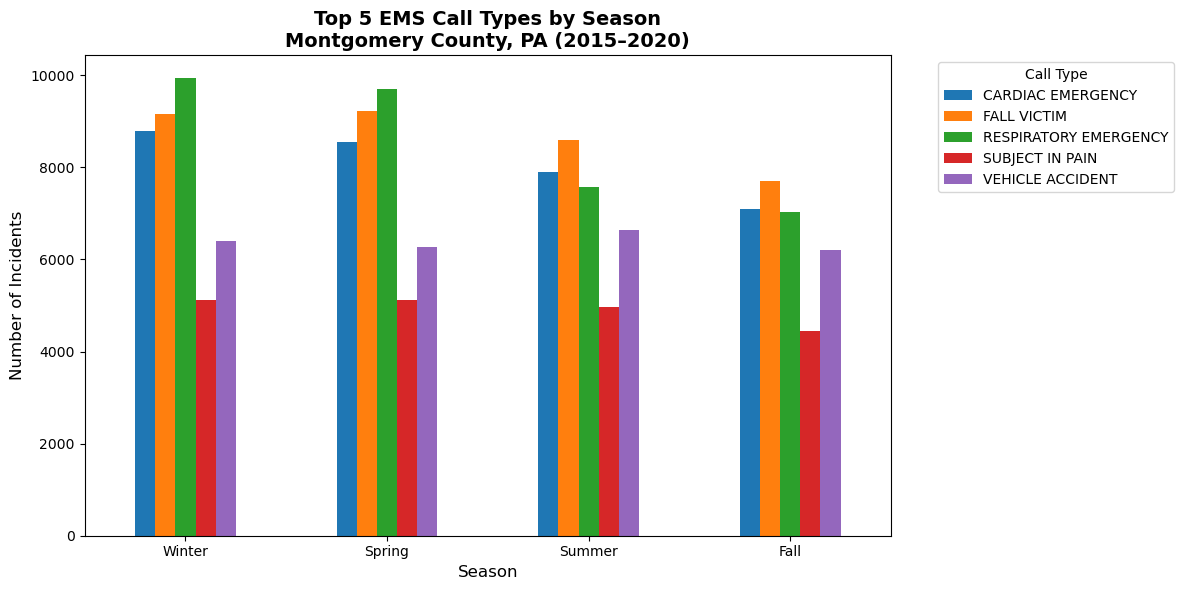

In [47]:
# Top 5 call types broken down by season
top_5 = df['call_type'].value_counts().head(5).index.tolist()
df_top5 = df[df['call_type'].isin(top_5)]

pivot_season = df_top5.groupby(['season', 'call_type']).size().unstack(fill_value=0)
pivot_season = pivot_season.reindex(season_order)

pivot_season.plot(kind='bar', figsize=(12, 6))
plt.title('Top 5 EMS Call Types by Season\nMontgomery County, PA (2015–2020)', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Call Type', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
# plt.savefig('call_types_by_season.png', dpi=150)  # uncomment to save
plt.show()

## Step 5: Target Variable Creation
Classify each hourly time window as Low, Medium, or High demand based on
county-level EMS literature benchmarks.

- **Low:** ≤6 calls/hour (rural/quiet periods)
- **Medium:** 7–10 calls/hour (moderate suburban demand)
- **High:** >10 calls/hour (peak urban demand)

In [17]:
# Hardcoded thresholds based on county level EMS literature
low_thresh = 6 # calls per hour
high_thresh = 10 # calls per hour

def classify_demand(count):
    if count <= low_thresh:
        return 'Low'
    elif count <= high_thresh:
        return 'Medium'
    else:
        return 'High'

hourly_counts['demand_level'] = hourly_counts['call_count'].apply(classify_demand)

print(f'Low/Medium threshold: {low_thresh} calls/hour')
print(f'Medium/High threshold: {high_thresh} calls/hour')
print(f'\nDemand level distribution:')
print(hourly_counts['demand_level'].value_counts().to_string())


Low/Medium threshold:  6 calls/hour
Medium/High threshold: 10 calls/hour

Demand level distribution:
demand_level
Low       15513
Medium    13042
High      11791


In [18]:
# Merge demand level back into main data
df = df.merge(hourly_counts[['date_hour', 'demand_level']], on='date_hour', how='left')

print(f'Demand levels assigned: {df["demand_level"].notna().sum():,} rows')
df[['timeStamp', 'hour', 'month', 'twp', 'call_type', 'demand_level']].head()


Demand levels assigned: 332,692 rows


,timeStamp,hour,month,twp,call_type,demand_level
0,2015-12-10 17:10:52,17,12,NEW HANOVER,BACK PAINS/INJURY,Low
1,2015-12-10 17:29:21,17,12,HATFIELD TOWNSHIP,DIABETIC EMERGENCY,Low
2,2015-12-10 16:47:36,16,12,NORRISTOWN,CARDIAC EMERGENCY,Low
3,2015-12-10 16:56:52,16,12,LOWER POTTSGROVE,DIZZINESS,Low
4,2015-12-10 15:39:04,15,12,LANSDALE,HEAD INJURY,Low


## Step 6: Model Training & Feature Layer Comparison
Models are trained in layers, starting with basic temporal features and
progressively adding geographic, seasonal, and contextual features.
Each layer is evaluated to determine whether it improves or hurts accuracy.

### 6a: Base Model: Hour + Month Only

In [19]:
# Base feature set: temporal only
base_features = ['hour', 'month']

X_base = df[base_features].fillna(0)
y = df['demand_level']

X_train, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42, stratify=y)

# Baseline (naive predictor)
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_pred)

# Random Forest
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
rf_base_acc = accuracy_score(y_test, rf_base.predict(X_test))

print(f'Baseline accuracy: {baseline_acc:.4f}')
print(f'RF (hour + month): {rf_base_acc:.4f}')
print(f'Improvement over baseline: + {rf_base_acc - baseline_acc:.4f} ({((rf_base_acc - baseline_acc)/baseline_acc)*100:.1f}%)')


Baseline accuracy: 0.4790
RF (hour + month): 0.6285
Improvement over baseline: +0.1495 (31.2%)


### 6b: Layer 2: Add Call Type

In [21]:
# Add call type encoding
feature_cols_v2 = (['hour', 'month'] + [c for c in df.columns if c.startswith('type_')])

X_v2 = df[feature_cols_v2].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X_v2, y, test_size=0.2, random_state=42, stratify=y)

rf_v2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_v2.fit(X_train, y_train)
rf_v2_acc = accuracy_score(y_test, rf_v2.predict(X_test))

print(f'RF (+ call type): {rf_v2_acc:.4f}')
print(f'Change from base: {rf_v2_acc - rf_base_acc:+.4f}')


RF (+ call type): 0.6172
Change from base: -0.0113


### 6c: Layer 3: Add Township

In [22]:
# Add township encoding
feature_cols_v3 = (['hour', 'month'] + [c for c in df.columns if c.startswith('type_')] + [c for c in df.columns if c.startswith('twp_')])

X_v3 = df[feature_cols_v3].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X_v3, y, test_size=0.2, random_state=42, stratify=y)

rf_v3 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_v3.fit(X_train, y_train)
rf_v3_acc = accuracy_score(y_test, rf_v3.predict(X_test))

print(f'RF (+ township): {rf_v3_acc:.4f}')
print(f'Change from previous: {rf_v3_acc - rf_v2_acc:+.4f}')


RF (+ township): 0.5639
Change from previous: -0.0533


### 6d: Layer 4: Add Day of Week, Season, Holiday

In [23]:
# Full feature set
feature_cols_full = (['hour', 'month', 'day_of_week', 'is_holiday'] + [c for c in df.columns if c.startswith('type_')] + [c for c in df.columns if c.startswith('twp_')] + [c for c in df.columns if c.startswith('season_')])

X_full = df[feature_cols_full].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42, stratify=y)

# Random Forest: full features
rf_full = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_full.fit(X_train, y_train)
y_pred_rf = rf_full.predict(X_test)
rf_full_acc = accuracy_score(y_test, y_pred_rf)

# XGBoost: full features
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_full = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)
xgb_full.fit(X_train, y_train_enc)
y_pred_xgb = le.inverse_transform(xgb_full.predict(X_test))
xgb_full_acc = accuracy_score(y_test, y_pred_xgb)

print(f'RF (full features): {rf_full_acc:.4f}')
print(f'XGB (full features): {xgb_full_acc:.4f}')
print(f'Change from previous (RF): {rf_full_acc - rf_v3_acc:+.4f}')


RF (full features): 0.5981
XGB (full features): 0.6365
Change from previous (RF): +0.0342


## Step 7: Results & Evaluation

### 7a: Feature Layer Accuracy Comparison

In [24]:
print("=" * 55)
print("FEATURE LAYER ACCURACY COMPARISON")
print("=" * 55)
print(f"Baseline (naive): {baseline_acc:.4f}")
print(f"RF — Hour + Month only: {rf_base_acc:.4f} ({((rf_base_acc-baseline_acc)/baseline_acc)*100:+.1f}% vs baseline)")
print(f"RF — + Call Type: {rf_v2_acc:.4f} ({((rf_v2_acc-baseline_acc)/baseline_acc)*100:+.1f}% vs baseline)")
print(f"RF — + Township: {rf_v3_acc:.4f} ({((rf_v3_acc-baseline_acc)/baseline_acc)*100:+.1f}% vs baseline)")
print(f"RF — Full Features: {rf_full_acc:.4f} ({((rf_full_acc-baseline_acc)/baseline_acc)*100:+.1f}% vs baseline)")
print(f"XGB — Full Features: {xgb_full_acc:.4f} ({((xgb_full_acc-baseline_acc)/baseline_acc)*100:+.1f}% vs baseline)")


FEATURE LAYER ACCURACY COMPARISON
Baseline (naive): 0.4790
RF — Hour + Month only: 0.6285 (+31.2% vs baseline)
RF — + Call Type: 0.6172 (+28.8% vs baseline)
RF — + Township: 0.5639 (+17.7% vs baseline)
RF — Full Features: 0.5981 (+24.9% vs baseline)
XGB — Full Features: 0.6365 (+32.9% vs baseline)


### 7b: Final Model Classification Reports

In [25]:
print("=" * 55)
print("CLASSIFICATION REPORT — Random Forest (Full Features)")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, target_names=['Low', 'Medium', 'High']))
print(f"Overall Accuracy: {rf_full_acc:.4f}")


CLASSIFICATION REPORT — Random Forest (Full Features)
              precision    recall  f1-score   support

         Low       0.66      0.76      0.71     31872
      Medium       0.63      0.58      0.60     12668
        High       0.45      0.38      0.41     21999

    accuracy                           0.60     66539
   macro avg       0.58      0.57      0.57     66539
weighted avg       0.59      0.60      0.59     66539

Overall Accuracy: 0.5981


In [26]:
print("=" * 55)
print("CLASSIFICATION REPORT — XGBoost (Full Features)")
print("=" * 55)
print(classification_report(y_test, y_pred_xgb, target_names=['Low', 'Medium', 'High']))
print(f"Overall Accuracy: {xgb_full_acc:.4f}")


CLASSIFICATION REPORT — XGBoost (Full Features)
              precision    recall  f1-score   support

         Low       0.66      0.87      0.75     31872
      Medium       0.68      0.62      0.65     12668
        High       0.51      0.30      0.38     21999

    accuracy                           0.64     66539
   macro avg       0.62      0.60      0.59     66539
weighted avg       0.62      0.64      0.61     66539

Overall Accuracy: 0.6365


### 7c: Confusion Matrices
### 7c 1: Random Forest

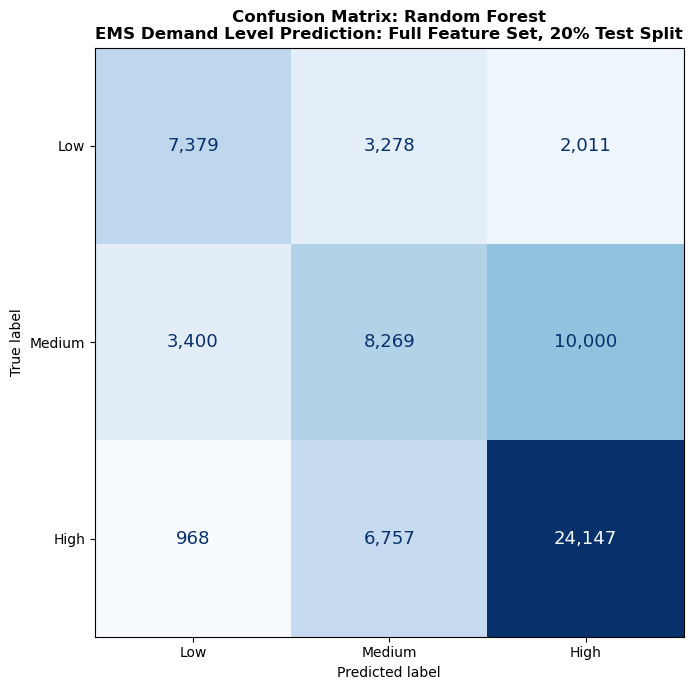

In [55]:
# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=['Low', 'Medium', 'High'])
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Low', 'Medium', 'High'])


fig, ax = plt.subplots(figsize=(8, 7))
disp_rf.plot(cmap='Blues', ax=ax, colorbar=False)

# Format numbers for clarity
for text in ax.texts:
    text.set_fontsize(13)
    val = float(text.get_text())
    text.set_text(f'{int(val):,}')

ax.set_title('Confusion Matrix: Random Forest\nEMS Demand Level Prediction: Full Feature Set, 20% Test Split', fontsize=12, fontweight='bold')
plt.tight_layout()
# plt.savefig('cm_random_forest.png', dpi=150)  # uncomment to save
plt.show()

### 7c 2: XGBoost Confusion Matrix

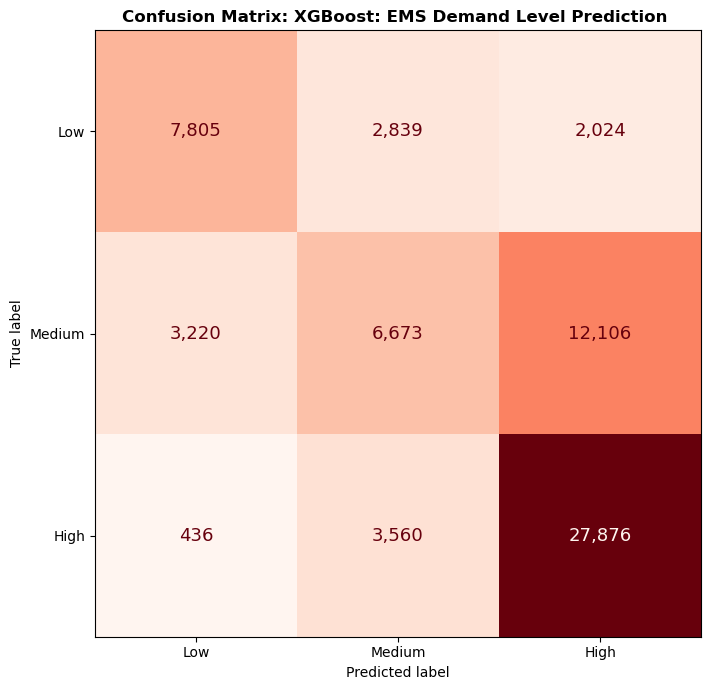

In [57]:
# XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=['Low', 'Medium', 'High'])
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Low', 'Medium', 'High'])


fig, ax = plt.subplots(figsize=(8, 7))
disp_xgb.plot(cmap='Reds', ax=ax, colorbar=False)

# Format numbers for clarity (same as above)
for text in ax.texts:
    text.set_fontsize(13)
    val = float(text.get_text())
    text.set_text(f'{int(val):,}')
    

ax.set_title('Confusion Matrix: XGBoost: EMS Demand Level Prediction ', fontsize=12, fontweight='bold')
plt.tight_layout()
# plt.savefig('cm_xgboost.png', dpi=150)  # uncomment to save
plt.show()


### 7d: Feature importance

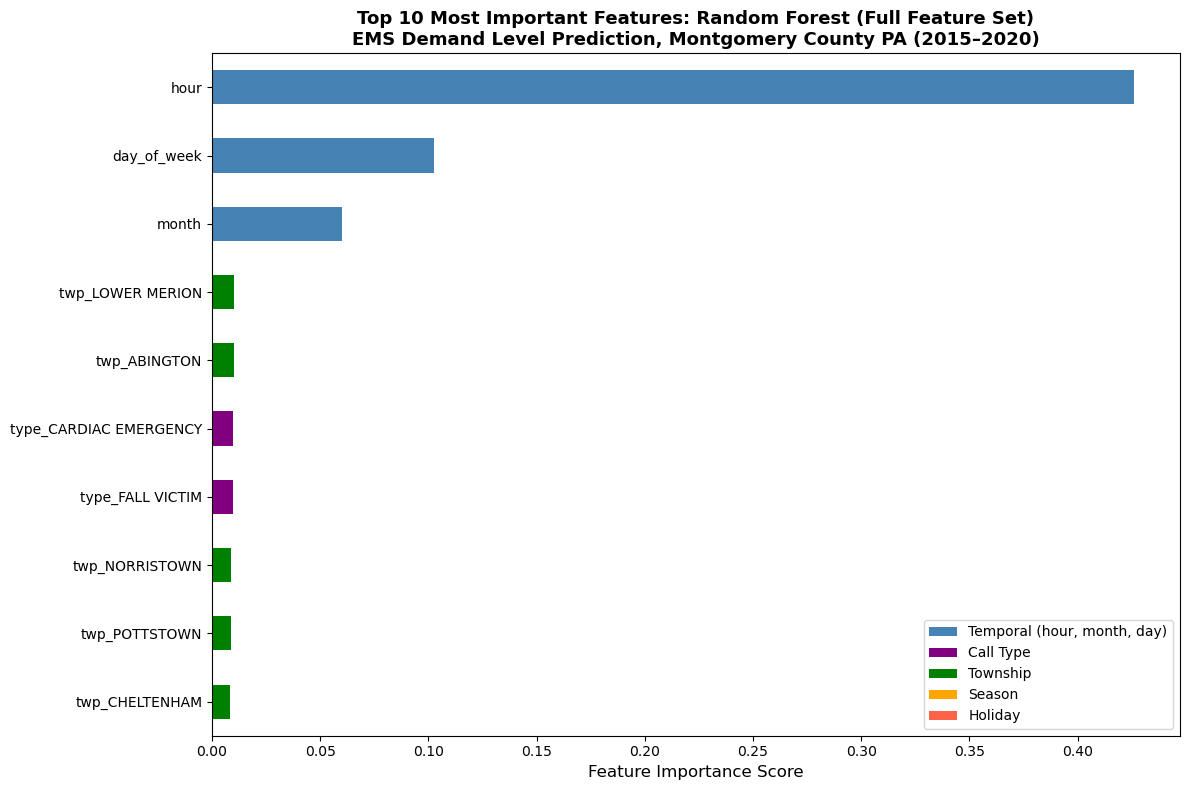

In [60]:
importances = pd.Series(rf_full.feature_importances_, index=feature_cols_full)
top_10 = importances.sort_values(ascending=False).head(10).sort_values()

# Color code by feature type
colors = []
for feat in top_10.index:
    if feat in ['hour', 'month', 'day_of_week']:
        colors.append('steelblue')
    elif feat == 'is_holiday':
        colors.append('tomato')
    elif feat.startswith('twp_'):
        colors.append('green')
    elif feat.startswith('season_'):
        colors.append('orange')
    else:
        colors.append('purple')  # call types

top_10.plot(kind='barh', color=colors, figsize=(12, 8))
plt.title('Top 10 Most Important Features: Random Forest (Full Feature Set)\nEMS Demand Level Prediction, Montgomery County PA (2015–2020)', fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score', fontsize=12)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Temporal (hour, month, day)'),
    Patch(facecolor='purple', label='Call Type'),
    Patch(facecolor='green', label='Township'),
    Patch(facecolor='orange', label='Season'),
    Patch(facecolor='tomato', label='Holiday')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
# plt.savefig('feature_importance_top10.png', dpi=150)  # uncomment to save
plt.show()


## Step 8: Prediction Demo
Enter an hour (0–23) and month (1–12) to predict EMS demand level.
Both Random Forest and XGBoost predictions are shown.

1. Input an hour between 0 and 23 (military time)
2. Input a month between 1 and 12
3. The model will predict the county-wide EMS demand level

In [ ]:
# User input with validation
while True:
    try:
        hour = int(input("Enter hour (0-23) "))
        if 0 <= hour <= 23:
            break
        else:
            print("Invalid input. Please enter a number between 0 and 23.")
    except ValueError:
        print("Invalid input. Please enter a whole number.")

while True:
    try:
        month = int(input("Enter month (1-12): "))
        if 1 <= month <= 12:
            break
        else:
            print("Invalid input. Please enter a number between 1 and 12.")
    except ValueError:
        print("Invalid input. Please enter a whole number.")

# Build sample with all features set to 0, then fill in temporal values
sample = pd.DataFrame(0, index=[0], columns=feature_cols_full)
sample['hour'] = hour
sample['month'] = month

# Predict
rf_pred = rf_full.predict(sample)[0]
xgb_pred = le.inverse_transform(xgb_full.predict(sample))[0]

print()
print("EMS DEMAND LEVEL PREDICTION")
print("=" * 45)
print(f"Hour: {hour}:00 (military time)")
print(f"Month: {month}")
print(f"\nRandom Forest: {rf_pred} Demand")
print(f"XGBoost: {xgb_pred} Demand")
